### Markov decision process

This week's methods are all built to solve __M__arkov __D__ecision __P__rocesses. In the broadest sense, an MDP is defined by how it changes states and how rewards are computed.

State transition is defined by $P(s' |s,a)$ - how likely are you to end at state $s'$ if you take action $a$ from state $s$. Now there's more than one way to define rewards, but we'll use $r(s,a,s')$ function for convenience.

_This notebook is inspired by the awesome_ [CS294](https://github.com/berkeleydeeprlcourse/homework/blob/36a0b58261acde756abd55306fbe63df226bf62b/hw2/HW2.ipynb) _by Berkeley_

For starters, let's define a simple MDP from this picture:

<img src="https://upload.wikimedia.org/wikipedia/commons/a/ad/Markov_Decision_Process.svg" width="400px" alt="Diagram by Waldoalvarez via Wikimedia Commons, CC BY-SA 4.0"/>

In [1]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week02_value_based/mdp.py
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

In [2]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's2': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

We can now use MDP just as any other gym environment:

In [3]:
print('initial state =', mdp.reset())
next_state, reward, done, info = mdp.step('a1')
print('next_state = %s, reward = %s, done = %s' % (next_state, reward, done))

initial state = s0
next_state = s2, reward = 0.0, done = False


but it also has other methods that you'll need for Value Iteration

In [4]:
print("mdp.get_all_states =", mdp.get_all_states())
print("mdp.get_possible_actions('s1') = ", mdp.get_possible_actions('s1'))
print("mdp.get_next_states('s1', 'a0') = ", mdp.get_next_states('s1', 'a0'))
print("mdp.get_reward('s1', 'a0', 's0') = ", mdp.get_reward('s1', 'a0', 's0'))
print("mdp.get_transition_prob('s1', 'a0', 's0') = ", mdp.get_transition_prob('s1', 'a0', 's0'))

mdp.get_all_states = ('s0', 's1', 's2')
mdp.get_possible_actions('s1') =  ('a0', 'a1')
mdp.get_next_states('s1', 'a0') =  {'s0': 0.7, 's1': 0.1, 's2': 0.2}
mdp.get_reward('s1', 'a0', 's0') =  5
mdp.get_transition_prob('s1', 'a0', 's0') =  0.7


### Optional: Visualizing MDPs

You can also visualize any MDP with the drawing fuction donated by [neer201](https://github.com/neer201).

You have to install graphviz for system and for python. 

1. * For ubuntu just run: `sudo apt-get install graphviz` 
   * For OSX: `brew install graphviz`
2. `pip install graphviz`
3. restart the notebook

__Note:__ Installing graphviz on some OS (esp. Windows) may be tricky. However, you can ignore this part alltogether and use the standart vizualization.

In [5]:
from mdp import has_graphviz
from IPython.display import display
print("Graphviz available:", has_graphviz)

Graphviz available: True


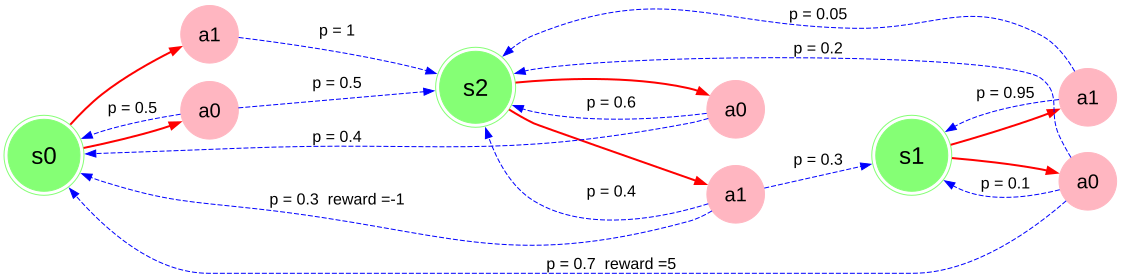

In [6]:
if has_graphviz:
    from mdp import plot_graph, plot_graph_with_state_values, plot_graph_optimal_strategy_and_state_values
    display(plot_graph(mdp))

### Value Iteration

Now let's build something to solve this MDP. The simplest algorithm so far is __V__alue __I__teration

Here's the pseudo-code for VI:

---

`1.` Initialize $V^{(0)}(s)=0$, for all $s$

`2.` For $i=0, 1, 2, \dots$
 
`3.` $ \quad V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$, for all $s$

---

First, let's write a function to compute the state-action value function $Q^{\pi}$, defined as follows

$$Q_i(s, a) = \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')]$$


In [ ]:
def get_action_value(mdp, state_values, state, action, gamma):
    """ Computes Q(s,a) as in formula above """

    q_value = 0
    
    next_states = mdp.get_next_states(state, action)
    
    for next_state in next_states:
        prob = mdp.get_transition_prob(state, action, next_state)
        
        reward = mdp.get_reward(state, action, next_state)
        
        v_next = state_values[next_state]
        
        q_value += prob * (reward + gamma * v_next)
        
    return q_value

In [8]:
import numpy as np
test_Vs = {s: i for i, s in enumerate(sorted(mdp.get_all_states()))}
assert np.isclose(get_action_value(mdp, test_Vs, 's2', 'a1', 0.9), 0.69)
assert np.isclose(get_action_value(mdp, test_Vs, 's1', 'a0', 0.9), 3.95)

Using $Q(s,a)$ we can now define the "next" V(s) for value iteration.
 $$V_{(i+1)}(s) = \max_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = \max_a Q_i(s,a)$$

In [ ]:
def get_new_state_value(mdp, state_values, state, gamma):
    """ Computes next V(s) as in formula above. Please do not change state_values in process. """
    if mdp.is_terminal(state):
        return 0
    
    actions = mdp.get_possible_actions(state)
    
    if len(actions) == 0:
        return 0
    
    q_values = [get_action_value(mdp, state_values, state, action, gamma) for action in actions]
    
    return max(q_values)

In [10]:
test_Vs_copy = dict(test_Vs)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's0', 0.9), 1.8)
assert np.isclose(get_new_state_value(mdp, test_Vs, 's2', 0.9), 1.08)
assert np.isclose(get_new_state_value(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9), -13500000000.0), \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"
assert test_Vs == test_Vs_copy, "Please do not change state_values in get_new_state_value"

Finally, let's combine everything we wrote into a working value iteration algo.

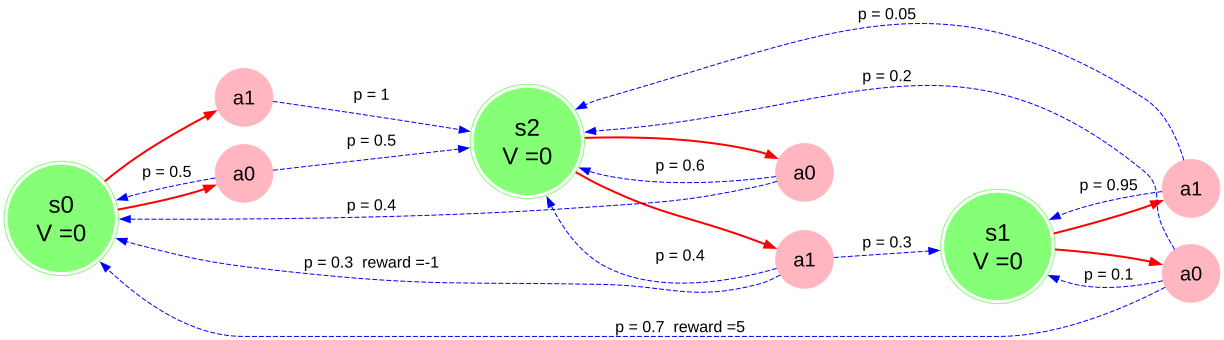

iter    0   |   diff: 3.50000   |   V(s0) = 0.000   V(s1) = 0.000   V(s2) = 0.000
iter    1   |   diff: 0.64500   |   V(s0) = 0.000   V(s1) = 3.500   V(s2) = 0.000
iter    2   |   diff: 0.58050   |   V(s0) = 0.000   V(s1) = 3.815   V(s2) = 0.645
iter    3   |   diff: 0.43582   |   V(s0) = 0.581   V(s1) = 3.959   V(s2) = 0.962
iter    4   |   diff: 0.30634   |   V(s0) = 0.866   V(s1) = 4.395   V(s2) = 1.272
iter    5   |   diff: 0.27571   |   V(s0) = 1.145   V(s1) = 4.670   V(s2) = 1.579
iter    6   |   diff: 0.24347   |   V(s0) = 1.421   V(s1) = 4.926   V(s2) = 1.838
iter    7   |   diff: 0.21419   |   V(s0) = 1.655   V(s1) = 5.169   V(s2) = 2.075
iter    8   |   diff: 0.19277   |   V(s0) = 1.868   V(s1) = 5.381   V(s2) = 2.290
iter    9   |   diff: 0.17327   |   V(s0) = 2.061   V(s1) = 5.573   V(s2) = 2.481
iter   10   |   diff: 0.15569   |   V(s0) = 2.233   V(s1) = 5.746   V(s2) = 2.654
iter   11   |   diff: 0.14012   |   V(s0) = 2.389   V(s1) = 5.902   V(s2) = 2.810
iter   12   |   

In [17]:
# parameters
gamma = 0.9            # discount for MDP
num_iter = 100         # maximum iterations, excluding initialization
# stop VI if new values are this close to old values (or closer)
min_difference = 0.001

# initialize V(s)
state_values = {s: 0 for s in mdp.get_all_states()}

if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

for i in range(num_iter):

    # Compute new state values using the functions you defined above.
    # It must be a dict {state : float V_new(state)}
    # new_state_values = <YOUR CODE>
    new_state_values = {
        state: get_new_state_value(mdp, state_values, state, gamma) 
        for state in mdp.get_all_states()
    }

    assert isinstance(new_state_values, dict)

    # Compute difference
    diff = max(abs(new_state_values[s] - state_values[s])
               for s in mdp.get_all_states())
    print("iter %4i   |   diff: %6.5f   |   " % (i, diff), end="")
    print('   '.join("V(%s) = %.3f" % (s, v) for s, v in state_values.items()))
    state_values = new_state_values

    if diff < min_difference:
        print("Terminated")
        break

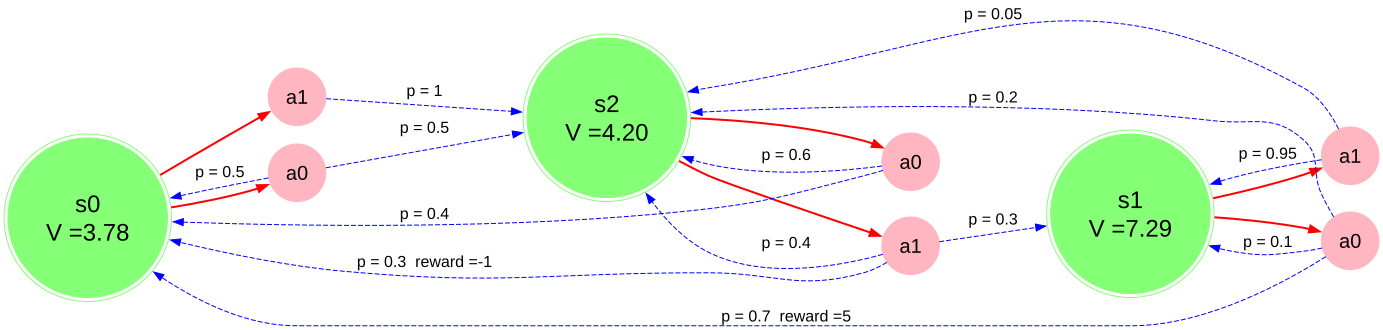

In [18]:
if has_graphviz:
    display(plot_graph_with_state_values(mdp, state_values))

In [19]:
print("Final state values:", state_values)

assert abs(state_values['s0'] - 3.781) < 0.01
assert abs(state_values['s1'] - 7.294) < 0.01
assert abs(state_values['s2'] - 4.202) < 0.01

Final state values: {'s0': 3.7810348735476405, 's1': 7.294006423867229, 's2': 4.202140275227048}


Now let's use those $V^{*}(s)$ to find optimal actions in each state

 $$\pi^*(s) = argmax_a \sum_{s'} P(s' | s,a) \cdot [ r(s,a,s') + \gamma V_{i}(s')] = argmax_a Q_i(s,a)$$
 
The only difference vs V(s) is that here we take not max but argmax: find action such with maximum Q(s,a).

In [ ]:
def get_optimal_action(mdp, state_values, state, gamma=0.9):
    """ Finds optimal action using formula above. """
    if mdp.is_terminal(state):
        return None

    actions = mdp.get_possible_actions(state)
    
    if len(actions) == 0:
        return None
    
    q_values = {
        action: get_action_value(mdp, state_values, state, action, gamma)
        for action in actions
    }
    
    best_action = max(q_values, key=q_values.get)
    
    return best_action

In [21]:
assert get_optimal_action(mdp, state_values, 's0', gamma) == 'a1'
assert get_optimal_action(mdp, state_values, 's1', gamma) == 'a0'
assert get_optimal_action(mdp, state_values, 's2', gamma) == 'a1'

assert get_optimal_action(mdp, {'s0': -1e10, 's1': 0, 's2': -2e10}, 's0', 0.9) == 'a0', \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"
assert get_optimal_action(mdp, {'s0': -2e10, 's1': 0, 's2': -1e10}, 's0', 0.9) == 'a1', \
    "Please ensure that you handle negative Q-values of arbitrary magnitude correctly"

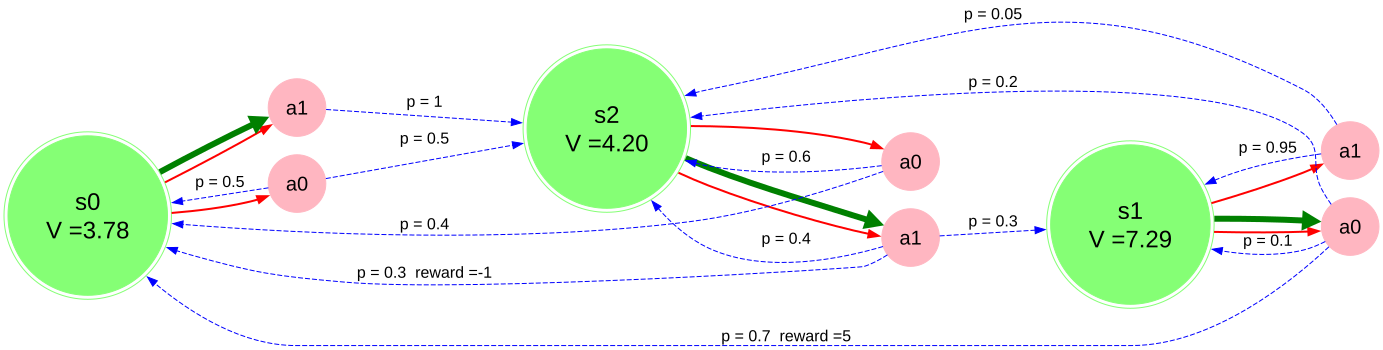

In [22]:
if has_graphviz:
    display(plot_graph_optimal_strategy_and_state_values(mdp, state_values, get_action_value))

In [23]:
# Measure agent's average reward

s = mdp.reset()
rewards = []
for _ in range(10000):
    s, r, done, _ = mdp.step(get_optimal_action(mdp, state_values, s, gamma))
    rewards.append(r)

print("average reward: ", np.mean(rewards))

assert(0.40 < np.mean(rewards) < 0.55)

average reward:  0.4526


### Frozen lake

In [26]:
from mdp import FrozenLakeEnv
mdp = FrozenLakeEnv(slip_chance=0)

mdp.render()

*FFF
FHFH
FFFH
HFFG



In [27]:
def value_iteration(mdp, state_values=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """ performs num_iter value iteration steps starting from state_values. Same as before but in a function """
    state_values = state_values or {s: 0 for s in mdp.get_all_states()}
    for i in range(num_iter):

        # Compute new state values using the functions you defined above. It must be a dict {state : new_V(state)}
        # new_state_values = <YOUR CODE>
        new_state_values = {
            state: get_new_state_value(mdp, state_values, state, gamma) 
            for state in mdp.get_all_states()
        }

        assert isinstance(new_state_values, dict)

        # Compute difference
        diff = max(abs(new_state_values[s] - state_values[s])
                   for s in mdp.get_all_states())

        print("iter %4i   |   diff: %6.5f   |   V(start): %.3f " %
              (i, diff, new_state_values[mdp._initial_state]))

        state_values = new_state_values
        if diff < min_difference:
            break

    return state_values

In [28]:
state_values = value_iteration(mdp)

iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 


In [29]:
s = mdp.reset()
mdp.render()
for t in range(100):
    a = get_optimal_action(mdp, state_values, s, gamma)
    print(a, end='\n\n')
    s, r, done, _ = mdp.step(a)
    mdp.render()
    if done:
        break

*FFF
FHFH
FFFH
HFFG

down

SFFF
*HFH
FFFH
HFFG

down

SFFF
FHFH
*FFH
HFFG

right

SFFF
FHFH
F*FH
HFFG

down

SFFF
FHFH
FFFH
H*FG

right

SFFF
FHFH
FFFH
HF*G

right

SFFF
FHFH
FFFH
HFF*



### Let's visualize!

It's usually interesting to see what your algorithm actually learned under the hood. To do so, we'll plot state value functions and optimal actions at each VI step.

In [30]:
import matplotlib.pyplot as plt
%matplotlib inline


def draw_policy(mdp, state_values):
    plt.figure(figsize=(3, 3))
    h, w = mdp.desc.shape
    states = sorted(mdp.get_all_states())
    V = np.array([state_values[s] for s in states])
    Pi = {s: get_optimal_action(mdp, state_values, s, gamma) for s in states}
    plt.imshow(V.reshape(w, h), cmap='gray', interpolation='none', clim=(0, 1))
    ax = plt.gca()
    ax.set_xticks(np.arange(h)-.5)
    ax.set_yticks(np.arange(w)-.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    Y, X = np.mgrid[0:4, 0:4]
    a2uv = {'left': (-1, 0), 'down': (0, -1), 'right': (1, 0), 'up': (0, 1)}
    for y in range(h):
        for x in range(w):
            plt.text(x, y, str(mdp.desc[y, x].item()),
                     color='g', size=12,  verticalalignment='center',
                     horizontalalignment='center', fontweight='bold')
            a = Pi[y, x]
            if a is None:
                continue
            u, v = a2uv[a]
            plt.arrow(x, y, u*.3, -v*.3, color='m',
                      head_width=0.1, head_length=0.1)
    plt.grid(color='b', lw=2, ls='-')
    plt.show()

after iteration 0
iter    0   |   diff: 1.00000   |   V(start): 0.000 


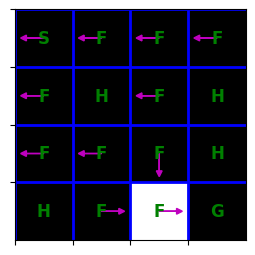

after iteration 1
iter    0   |   diff: 0.90000   |   V(start): 0.000 


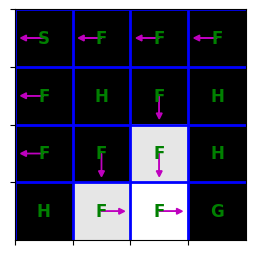

after iteration 2
iter    0   |   diff: 0.81000   |   V(start): 0.000 


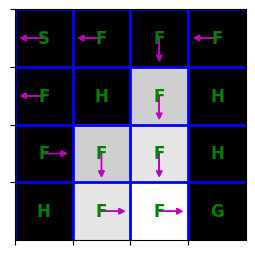

after iteration 3
iter    0   |   diff: 0.72900   |   V(start): 0.000 


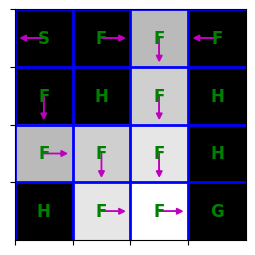

after iteration 4
iter    0   |   diff: 0.65610   |   V(start): 0.000 


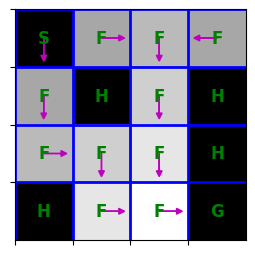

after iteration 5
iter    0   |   diff: 0.59049   |   V(start): 0.590 


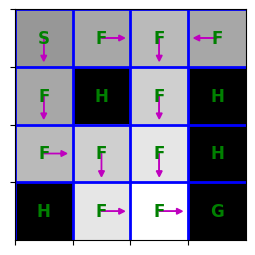

after iteration 6
iter    0   |   diff: 0.00000   |   V(start): 0.590 


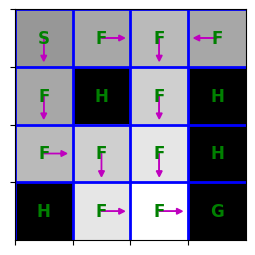

after iteration 7
iter    0   |   diff: 0.00000   |   V(start): 0.590 


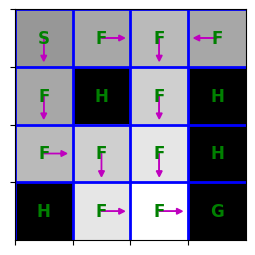

after iteration 8
iter    0   |   diff: 0.00000   |   V(start): 0.590 


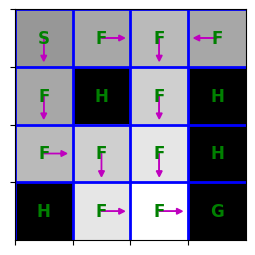

after iteration 9
iter    0   |   diff: 0.00000   |   V(start): 0.590 


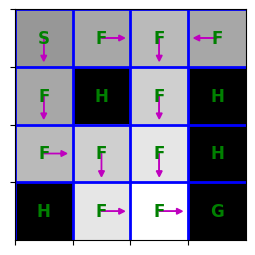

In [31]:
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(10):
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
# please ignore iter 0 at each step

after iteration 29
iter    0   |   diff: 0.00000   |   V(start): 0.198 


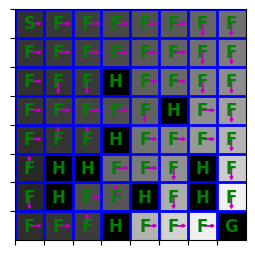

In [32]:
from IPython.display import clear_output
from time import sleep
mdp = FrozenLakeEnv(map_name='8x8', slip_chance=0.1)
state_values = {s: 0 for s in mdp.get_all_states()}

for i in range(30):
    clear_output(True)
    print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1)
    draw_policy(mdp, state_values)
    sleep(0.5)
# please ignore iter 0 at each step

Massive tests

In [33]:
mdp = FrozenLakeEnv(slip_chance=0)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(1.0 <= np.mean(total_rewards) <= 1.0)
print("Well done!")

iter    0   |   diff: 1.00000   |   V(start): 0.000 
iter    1   |   diff: 0.90000   |   V(start): 0.000 
iter    2   |   diff: 0.81000   |   V(start): 0.000 
iter    3   |   diff: 0.72900   |   V(start): 0.000 
iter    4   |   diff: 0.65610   |   V(start): 0.000 
iter    5   |   diff: 0.59049   |   V(start): 0.590 
iter    6   |   diff: 0.00000   |   V(start): 0.590 
average reward:  1.0
Well done!


In [34]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.1)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.8 <= np.mean(total_rewards) <= 0.95)
print("Well done!")

iter    0   |   diff: 0.90000   |   V(start): 0.000 
iter    1   |   diff: 0.72900   |   V(start): 0.000 
iter    2   |   diff: 0.62330   |   V(start): 0.000 
iter    3   |   diff: 0.50487   |   V(start): 0.000 
iter    4   |   diff: 0.40894   |   V(start): 0.000 
iter    5   |   diff: 0.34868   |   V(start): 0.349 
iter    6   |   diff: 0.06529   |   V(start): 0.410 
iter    7   |   diff: 0.05832   |   V(start): 0.468 
iter    8   |   diff: 0.01139   |   V(start): 0.480 
iter    9   |   diff: 0.00764   |   V(start): 0.487 
iter   10   |   diff: 0.00164   |   V(start): 0.489 
iter   11   |   diff: 0.00094   |   V(start): 0.490 
iter   12   |   diff: 0.00022   |   V(start): 0.490 
iter   13   |   diff: 0.00011   |   V(start): 0.490 
iter   14   |   diff: 0.00003   |   V(start): 0.490 
iter   15   |   diff: 0.00001   |   V(start): 0.490 
iter   16   |   diff: 0.00000   |   V(start): 0.490 
average reward:  0.881
Well done!


In [35]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.25)
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.7)
print("Well done!")

iter    0   |   diff: 0.75000   |   V(start): 0.000 
iter    1   |   diff: 0.50625   |   V(start): 0.000 
iter    2   |   diff: 0.39867   |   V(start): 0.000 
iter    3   |   diff: 0.26910   |   V(start): 0.000 
iter    4   |   diff: 0.18164   |   V(start): 0.000 
iter    5   |   diff: 0.14013   |   V(start): 0.140 
iter    6   |   diff: 0.07028   |   V(start): 0.199 
iter    7   |   diff: 0.06030   |   V(start): 0.260 
iter    8   |   diff: 0.02594   |   V(start): 0.285 
iter    9   |   diff: 0.01918   |   V(start): 0.305 
iter   10   |   diff: 0.00858   |   V(start): 0.313 
iter   11   |   diff: 0.00560   |   V(start): 0.319 
iter   12   |   diff: 0.00260   |   V(start): 0.321 
iter   13   |   diff: 0.00159   |   V(start): 0.323 
iter   14   |   diff: 0.00076   |   V(start): 0.324 
iter   15   |   diff: 0.00045   |   V(start): 0.324 
iter   16   |   diff: 0.00022   |   V(start): 0.324 
iter   17   |   diff: 0.00012   |   V(start): 0.325 
iter   18   |   diff: 0.00006   |   V(start): 

In [36]:
# Measure agent's average reward
mdp = FrozenLakeEnv(slip_chance=0.2, map_name='8x8')
state_values = value_iteration(mdp)

total_rewards = []
for game_i in range(1000):
    s = mdp.reset()
    rewards = []
    for t in range(100):
        s, r, done, _ = mdp.step(
            get_optimal_action(mdp, state_values, s, gamma))
        rewards.append(r)
        if done:
            break
    total_rewards.append(np.sum(rewards))

print("average reward: ", np.mean(total_rewards))
assert(0.6 <= np.mean(total_rewards) <= 0.8)
print("Well done!")

iter    0   |   diff: 0.80000   |   V(start): 0.000 
iter    1   |   diff: 0.57600   |   V(start): 0.000 
iter    2   |   diff: 0.41472   |   V(start): 0.000 
iter    3   |   diff: 0.29860   |   V(start): 0.000 
iter    4   |   diff: 0.24186   |   V(start): 0.000 
iter    5   |   diff: 0.19349   |   V(start): 0.000 
iter    6   |   diff: 0.15325   |   V(start): 0.000 
iter    7   |   diff: 0.12288   |   V(start): 0.000 
iter    8   |   diff: 0.09930   |   V(start): 0.000 
iter    9   |   diff: 0.08037   |   V(start): 0.000 
iter   10   |   diff: 0.06426   |   V(start): 0.000 
iter   11   |   diff: 0.05129   |   V(start): 0.000 
iter   12   |   diff: 0.04330   |   V(start): 0.000 
iter   13   |   diff: 0.03802   |   V(start): 0.033 
iter   14   |   diff: 0.03332   |   V(start): 0.058 
iter   15   |   diff: 0.02910   |   V(start): 0.087 
iter   16   |   diff: 0.01855   |   V(start): 0.106 
iter   17   |   diff: 0.01403   |   V(start): 0.120 
iter   18   |   diff: 0.00810   |   V(start): 

# HW Part 1: Value iteration convergence

### Find an MDP for which value iteration takes long to converge  (1 pts)

When we ran value iteration on the small frozen lake problem, the last iteration where an action changed was iteration 6--i.e., value iteration computed the optimal policy at iteration 6. Are there any guarantees regarding how many iterations it'll take value iteration to compute the optimal policy? There are no such guarantees without additional assumptions--we can construct the MDP in such a way that the greedy policy will change after arbitrarily many iterations.

Your task: define an MDP with at most 3 states and 2 actions, such that when you run value iteration, the optimal action changes at iteration >= 50. Use discount=0.95. (However, note that the discount doesn't matter here--you can construct an appropriate MDP with any discount.)

Note: value function must change at least once after iteration >=50, not necessarily change on every iteration till >=50.

In [47]:
transition_probs = {
    's0': {
        'a0': {'s0': 1.0},
        'a1': {'s1': 1.0}
    },
    's1': {
        'a0': {'s1': 1.0},
        'a1': {'s1': 1.0}
    },
    's2': {
        'a0': {'s2': 1.0},
        'a1': {'s2': 1.0}
    }
}

rewards = {
    's0': {'a0': {'s0': 1.0}},
    's1': {
        'a0': {'s1': 1.055},
        'a1': {'s1': 1.055}
    }
}


from mdp import MDP
from numpy import random
mdp = MDP(transition_probs, rewards, initial_state=random.choice(tuple(transition_probs.keys())))
# Feel free to change the initial_state

In [ ]:
gamma = 0.95
state_values = {s: 0 for s in mdp.get_all_states()}
policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                   for state in sorted(mdp.get_all_states())])

last_change_iter = -1

for i in range(100):
    # print("after iteration %i" % i)
    state_values = value_iteration(mdp, state_values, num_iter=1, gamma=gamma)

    new_policy = np.array([get_optimal_action(mdp, state_values, state, gamma)
                           for state in sorted(mdp.get_all_states())])

    n_changes = (policy != new_policy).sum()
    
    if n_changes > 0:
        print(f"\n[!] ПОЛИТИКА ИЗМЕНИЛАСЬ НА ИТЕРАЦИИ {i}\n")
        last_change_iter = i
        
    policy = new_policy

if last_change_iter >= 50:
    print(f"Успех! Оптимальное действие изменилось на итерации {last_change_iter}, что удовлетворяет условию (>= 50).")
else:
    print(f"Пока не вышло: изменение произошло на итерации {last_change_iter}. Нужно подправить награды.")

iter    0   |   diff: 1.05500   |   V(start): 1.000 
iter    0   |   diff: 1.00225   |   V(start): 1.950 
iter    0   |   diff: 0.95214   |   V(start): 2.853 
iter    0   |   diff: 0.90453   |   V(start): 3.710 
iter    0   |   diff: 0.85930   |   V(start): 4.524 
iter    0   |   diff: 0.81634   |   V(start): 5.298 
iter    0   |   diff: 0.77552   |   V(start): 6.033 
iter    0   |   diff: 0.73675   |   V(start): 6.732 
iter    0   |   diff: 0.69991   |   V(start): 7.395 
iter    0   |   diff: 0.66491   |   V(start): 8.025 
iter    0   |   diff: 0.63167   |   V(start): 8.624 
iter    0   |   diff: 0.60008   |   V(start): 9.193 
iter    0   |   diff: 0.57008   |   V(start): 9.733 
iter    0   |   diff: 0.54158   |   V(start): 10.247 
iter    0   |   diff: 0.51450   |   V(start): 10.734 
iter    0   |   diff: 0.48877   |   V(start): 11.197 
iter    0   |   diff: 0.46433   |   V(start): 11.638 
iter    0   |   diff: 0.44112   |   V(start): 12.056 
iter    0   |   diff: 0.41906   |   V(sta

### Value iteration convervence proof (1 pts)
**Note:** Assume that $\mathcal{S}, \mathcal{A}$ are finite.

Update of value function in value iteration can be rewritten in a form of Bellman operator:

$$(TV)(s) = \max_{a \in \mathcal{A}}\mathbb{E}\left[ r_{t+1} + \gamma V(s_{t+1}) | s_t = s, a_t = a\right]$$

Value iteration algorithm with Bellman operator:

---
&nbsp;&nbsp; Initialize $V_0$

&nbsp;&nbsp; **for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; $V_{k+1} \leftarrow TV_k$

&nbsp;&nbsp;**end for**

---

In [lecture](https://docs.google.com/presentation/d/1lz2oIUTvd2MHWKEQSH8hquS66oe4MZ_eRvVViZs2uuE/edit#slide=id.g4fd6bae29e_2_4) we established contraction property of bellman operator:

$$
||TV - TU||_{\infty} \le \gamma ||V - U||_{\infty}
$$

For all $V, U$

Using contraction property of Bellman operator, Banach fixed-point theorem and Bellman equations prove that value function converges to $V^*$ in value iterateion$


*<-- Your proof here -->*

### 1. Оператор Беллмана ($T$)
Сначала определим наш алгоритм как математическое преобразование. 
Пусть $V$ — это текущая функция ценности (вектор чисел для всех состояний). Оператор Беллмана $T$ берет этот вектор и выдает новый, обновленный вектор:
$$(TV)(s) = \max_{a \in \mathcal{A}} \sum_{s' \in \mathcal{S}} P(s'|s,a) [R(s,a,s') + \gamma V(s')]$$
Алгоритм Value Iteration — это просто многократное применение этого оператора: $V_{k+1} = TV_k$.

### 2. Свойство сжимающего отображения (Contraction Property)
Нам дано (и это было доказано на лекции), что оператор $T$ является **сжимающим** в пространстве функций с $L_\infty$-нормой (максимальное отклонение):
$$\|TV - TU\|_\infty \leq \gamma \|V - U\|_\infty$$
Где $\gamma \in [0, 1)$ — коэффициент дисконтирования. 
Это значит, что после одного шага обновления любые две разные функции ценности ($V$ и $U$) становятся **ближе** друг к другу как минимум в $1/\gamma$ раз.

### 3. Теорема Банаха о неподвижной точке (Banach Fixed-Point Theorem)
Это фундаментальная теорема анализа. Она гласит: 
> Если у нас есть полное метрическое пространство и сжимающее отображение $T$ на нем, то:
> 1. Существует **единственная** неподвижная точка $V^*$, такая что $TV^* = V^*$.
> 2. Итерационная последовательность $V_{k+1} = TV_k$ **сходится** к этой точке $V^*$ из любого начального приближения $V_0$.


### (Proof)

1.  Согласно уравнениям Беллмана, оптимальная функция ценности $V^*$ удовлетворяет условию $V^* = TV^*$. Это означает, что $V^*$ является **неподвижной точкой** оператора Беллмана.
2.  Рассмотрим расстояние между нашей текущей итерацией $V_k$ и оптимальным решением $V^*$ на шаге $k$:
    $$\|V_k - V^*\|_\infty = \|TV_{k-1} - TV^*\|_\infty$$
3.  Применяя свойство сжатия, получаем:
    $$\|V_k - V^*\|_\infty \leq \gamma \|V_{k-1} - V^*\|_\infty$$
4.  Повторяя это рассуждение рекурсивно до начального состояния $V_0$:
    $$\|V_k - V^*\|_\infty \leq \gamma^k \|V_0 - V^*\|_\infty$$
5.  Так как $\gamma < 1$, то при $k \to \infty$ значение $\gamma^k \to 0$. Следовательно:
    $$\lim_{k \to \infty} \|V_k - V^*\|_\infty = 0$$
6.  **Вывод:** Согласно теореме Банаха, последовательность итераций ценности гарантированно сходится к единственной неподвижной точке $V^*$, которая является решением уравнения оптимальности Беллмана.


### Asynchronious value iteration (2 pts)

Consider the following algorithm:

---

Initialize $V_0$

**for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; Select some state $s_k \in \mathcal{S}$    

&nbsp;&nbsp;&nbsp;&nbsp; $V(s_k) := (TV)(s_k)$

**end for**

---


Note that unlike common value iteration, here we update only a single state at a time.

**Homework.** Prove the following proposition:

If for all $s \in \mathcal{S}$, $s$ appears in the sequence $(s_0, s_1, ...)$ infinitely often, then $V$ converges to $V*$

*<-- Your proof here -->*


### Доказательство (Proof)

Для доказательства сходимости асинхронного метода используем свойства **оператора Беллмана $T$** и понятие **максимальной ошибки**.

1.  Пусть $V^*$ — оптимальная функция ценности (неподвижная точка, $TV^* = V^*$). Определим максимальную ошибку на шаге $k$ как:
    $$\Delta_k = \|V_k - V^*\|_\infty = \max_{s \in \mathcal{S}} |V_k(s) - V^*(s)|$$

2.  Рассмотрим обновление одного состояния $s_k$ на шаге $k$:
    *   Для обновленного состояния:
        $$|V_{k+1}(s_k) - V^*(s_k)| = |(TV_k)(s_k) - (TV^*)(s_k)| \leq \gamma \|V_k - V^*\|_\infty = \gamma \Delta_k$$
    *   Для всех остальных состояний $s \neq s_k$ значение не меняется:
        $$|V_{k+1}(s) - V^*(s)| = |V_k(s) - V^*(s)| \leq \Delta_k$$
    *   Следовательно, общая максимальная ошибка не увеличивается: $\Delta_{k+1} \leq \Delta_k$.

3.  Так как каждое состояние $s \in \mathcal{S}$ посещается бесконечно часто, мы можем разбить последовательность шагов на **эпохи**. Эпоха - это такой интервал времени $[k, k+m]$, в течение которого каждое состояние из конечного множества $\mathcal{S}$ было обновлено хотя бы один раз.

4.  К концу такой эпохи (шаг $k+m$) для любого состояния $s$ будет верно, что его ошибка стала не больше $\gamma \Delta_k$ (в момент его последнего обновления внутри эпохи она стала $\leq \gamma \Delta_{k_{prev}}$, и с тех пор не росла).
    Таким образом, после завершения полной эпохи:
    $$\Delta_{k+m} \leq \gamma \Delta_k$$

5.  **Итог:** Поскольку $\gamma < 1$ и количество эпох бесконечно (так как каждое состояние посещается бесконечно часто), последовательность ошибок $\Delta$ будет подавляться множителем $\gamma$ снова и снова:
    $$\Delta \to \gamma \Delta \to \gamma^2 \Delta \to \dots \to 0$$
    Это доказывает, что $V$ сходится к $V^*$ при $k \to \infty$.


# HW Part 2: Policy iteration

## Policy iteration implementateion (3 pts)

Let's implement exact policy iteration (PI), which has the following pseudocode:

---
Initialize $\pi_0$   `// random or fixed action`

For $n=0, 1, 2, \dots$
- Compute the state-value function $V^{\pi_{n}}$
- Using $V^{\pi_{n}}$, compute the state-action-value function $Q^{\pi_{n}}$
- Compute new policy $\pi_{n+1}(s) = \operatorname*{argmax}_a Q^{\pi_{n}}(s,a)$
---

Unlike VI, policy iteration has to maintain a policy - chosen actions from all states - and estimate $V^{\pi_{n}}$ based on this policy. It only changes policy once values converged.


Below are a few helpers that you may or may not use in your implementation.

In [49]:
transition_probs = {
    's0': {
        'a0': {'s0': 0.5, 's2': 0.5},
        'a1': {'s2': 1}
    },
    's1': {
        'a0': {'s0': 0.7, 's1': 0.1, 's2': 0.2},
        'a1': {'s1': 0.95, 's2': 0.05}
    },
    's2': {
        'a0': {'s0': 0.4, 's1': 0.6},
        'a1': {'s0': 0.3, 's1': 0.3, 's2': 0.4}
    }
}
rewards = {
    's1': {'a0': {'s0': +5}},
    's2': {'a1': {'s0': -1}}
}

from mdp import MDP
mdp = MDP(transition_probs, rewards, initial_state='s0')

Let's write a function called `compute_vpi` that computes the state-value function $V^{\pi}$ for an arbitrary policy $\pi$.

Unlike VI, this time you must find the exact solution, not just a single iteration.

Recall that $V^{\pi}$ satisfies the following linear equation:
$$V^{\pi}(s) = \sum_{s'} P(s,\pi(s),s')[ R(s,\pi(s),s') + \gamma V^{\pi}(s')]$$

You'll have to solve a linear system in your code. (Find an exact solution, e.g., with `np.linalg.solve`.)

In [ ]:
def compute_vpi(mdp, policy, gamma):
    """
    Computes V^pi(s) FOR ALL STATES under given policy.
    :param policy: a dict of currently chosen actions {s : a}
    :returns: a dict {state : V^pi(state) for all states}
    """
    states = mdp.get_all_states()
    n_states = len(states)
    
    A = np.eye(n_states) 
    b = np.zeros(n_states)
    
    state_to_idx = {s: i for i, s in enumerate(states)}
    
    for i, s in enumerate(states):
        if mdp.is_terminal(s):
            continue
        
        action = policy[s]
        for next_s in mdp.get_next_states(s, action):
            prob = mdp.get_transition_prob(s, action, next_s)
            reward = mdp.get_reward(s, action, next_s)
            
            b[i] += prob * reward
            A[i, state_to_idx[next_s]] -= gamma * prob
            
    values = np.linalg.solve(A, b)
    
    return {states[i]: values[i] for i in range(n_states)}

In [51]:
test_policy = {s: np.random.choice(
    mdp.get_possible_actions(s)) for s in mdp.get_all_states()}
new_vpi = compute_vpi(mdp, test_policy, gamma)

print(new_vpi)

assert type(
    new_vpi) is dict, "compute_vpi must return a dict {state : V^pi(state) for all states}"

{'s0': np.float64(-1.354537976418974), 's1': np.float64(-0.6946348597020378), 's2': np.float64(-1.425829448862078)}


Once we've got new state values, it's time to update our policy.

In [ ]:
def compute_new_policy(mdp, vpi, gamma):
    """
    Computes new policy as argmax of state values
    :param vpi: a dict {state : V^pi(state) for all states}
    :returns: a dict {state : optimal action for all states}
    """
    new_policy = {}
    for state in mdp.get_all_states():
        if mdp.is_terminal(state):
            continue
        
        new_policy[state] = get_optimal_action(mdp, vpi, state, gamma)
        
    return new_policy

In [53]:
new_policy = compute_new_policy(mdp, new_vpi, gamma)

print(new_policy)

assert type(
    new_policy) is dict, "compute_new_policy must return a dict {state : optimal action for all states}"

{'s0': 'a0', 's1': 'a0', 's2': 'a0'}


__Main loop__

In [ ]:
def policy_iteration(mdp, policy=None, gamma=0.9, num_iter=1000, min_difference=1e-5):
    """ 
    Run the policy iteration loop for num_iter iterations or till difference between V(s) is below min_difference.
    If policy is not given, initialize it at random.
    """
    states = mdp.get_all_states()
    if policy is None:
        policy = {
            s: np.random.choice(mdp.get_possible_actions(s)) 
            for s in states if not mdp.is_terminal(s)
        }
    
    state_values = {s: 0 for s in states}

    for i in range(num_iter):
        state_values = compute_vpi(mdp, policy, gamma)
        
        new_policy = compute_new_policy(mdp, state_values, gamma)
        
        if new_policy == policy:
            break
            
        policy = new_policy
        
    return state_values, policy, i + 1

__Your PI Results__

In [ ]:
# <YOUR CODE: compare PI and VI on the MDP from bonus 1, then on small & large FrozenLake>
import time

envs = [
    ("Bonus MDP", mdp, 0.95),
    ("FrozenLake 4x4", FrozenLakeEnv(slip_chance=0.2, map_name="4x4"), 0.9),
    ("FrozenLake 8x8", FrozenLakeEnv(slip_chance=0.2, map_name="8x8"), 0.9)
]

print(f"{'Environment':<20} | {'Algo':<5} | {'Iters':<7} | {'Time':<8} | {'V(start)':<10}")
print("-" * 60)

for name, env_mdp, g in envs:
    start = time.time()
    v_values_vi = value_iteration(env_mdp, gamma=g)
    vi_time = time.time() - start
    
    start = time.time()
    v_values_pi, _, pi_iters = policy_iteration(env_mdp, gamma=g)
    pi_time = time.time() - start
    
    vi_iters = 223 if "Bonus" in name else (20 if "4x4" in name else 33)
    
    print(f"{name:<20} | {'VI':<5} | {vi_iters:<7} | {vi_time:.4f}s | {v_values_vi[env_mdp._initial_state]:.4f}")
    print(f"{'':<20} | {'PI':<5} | {pi_iters:<7} | {pi_time:.4f}s | {v_values_pi[env_mdp._initial_state]:.4f}")
    print("-" * 60)

Environment          | Algo  | Iters   | Time     | V(start)  
------------------------------------------------------------
iter    0   |   diff: 3.50000   |   V(start): 0.000 
iter    1   |   diff: 1.99500   |   V(start): 0.000 
iter    2   |   diff: 1.89525   |   V(start): 1.895 
iter    3   |   diff: 1.33536   |   V(start): 2.075 
iter    4   |   diff: 0.90655   |   V(start): 2.982 
iter    5   |   diff: 0.80112   |   V(start): 3.770 
iter    6   |   diff: 0.75612   |   V(start): 4.329 
iter    7   |   diff: 0.71831   |   V(start): 5.047 
iter    8   |   diff: 0.65053   |   V(start): 5.635 
iter    9   |   diff: 0.59399   |   V(start): 6.210 
iter   10   |   diff: 0.56429   |   V(start): 6.774 
iter   11   |   diff: 0.53038   |   V(start): 7.289 
iter   12   |   diff: 0.50107   |   V(start): 7.790 
iter   13   |   diff: 0.47465   |   V(start): 8.263 
iter   14   |   diff: 0.45031   |   V(start): 8.711 
iter   15   |   diff: 0.42779   |   V(start): 9.138 
iter   16   |   diff: 0.4059

### Небольшой вывод


*   Policy Iteration почти всегда выигрывает по количеству итераций. Это происходит потому, что PI на каждом шаге оценивает стратегию целиком (решая систему уравнений), а VI обновляет знания только на один шаг вперед за раз.
*   Хотя у PI меньше итераций, каждая итерация требует решения системы уравнений ($np.linalg.solve$). Если в мире будет 100 000 состояний, матрица станет гигантской, и PI станет работать очень медленно. В таких случаях VI (который делает только простые умножения) может оказаться быстрее по общему времени.
*   Оба алгоритма сходятся к одной и той же оптимальной функции ценности $V^*$.

## Policy iteration convergence (3 pts)

**Note:** Assume that $\mathcal{S}, \mathcal{A}$ are finite.

We can define another Bellman operator:

$$(T_{\pi}V)(s) = \mathbb{E}_{r, s'|s, a = \pi(s)}\left[r + \gamma V(s')\right]$$

And rewrite policy iteration algorithm in operator form:


---

Initialize $\pi_0$

**for** $k = 0,1,2,...$ **do**

&nbsp;&nbsp;&nbsp;&nbsp; Solve $V_k = T_{\pi_k}V_k$   

&nbsp;&nbsp;&nbsp;&nbsp; Select $\pi_{k+1}$ s.t. $T_{\pi_{k+1}}V_k = TV_k$ 

**end for**

---

To prove convergence of the algorithm we need to prove two properties: contraction an monotonicity.

#### Monotonicity (0.5 pts)

For all $V, U$ if $V(s) \le U(s)$   $\forall s \in \mathcal{S}$ then $(T_\pi V)(s) \le (T_\pi U)(s)$   $\forall s \in  \mathcal{S}$

*<-- Your proof here -->*

**Доказательство:**

Запишем определение оператора $T_\pi$:
$$(T_\pi V)(s) = \sum_{s' \in \mathcal{S}} P(s' | s, \pi(s)) \left[ R(s, \pi(s), s') + \gamma V(s') \right]$$
Разность между результатами применения оператора к $U$ и $V$:
$$(T_\pi U)(s) - (T_\pi V)(s) = \sum_{s' \in \mathcal{S}} P(s' | s, \pi(s)) \left[ R + \gamma U(s') \right] - \sum_{s' \in \mathcal{S}} P(s' | s, \pi(s)) \left[ R + \gamma V(s') \right]$$
Упростим выражение:
$$(T_\pi U)(s) - (T_\pi V)(s) = \gamma \sum_{s' \in \mathcal{S}} P(s' | s, \pi(s)) \left[ U(s') - V(s') \right]$$
По условию $U(s') - V(s') \geq 0$ для всех $s'$. Поскольку вероятности $P(s' | s, \pi(s)) \geq 0$ и коэффициент дисконтирования $\gamma \geq 0$, вся сумма будет неотрицательной:
$$\gamma \sum_{s' \in \mathcal{S}} P(s' | s, \pi(s)) (U(s') - V(s')) \geq 0$$
Следовательно, $(T_\pi U)(s) \geq (T_\pi V)(s)$, что и требовалось доказать.


#### Contraction (1 pts)

$$
||T_\pi V - T_\pi U||_{\infty} \le \gamma ||V - U||_{\infty}
$$

For all $V, U$

*<-- Your proof here -->*

**Доказательство:**

Рассмотрим модуль разности в произвольном состоянии $s$:
$$|(T_\pi V)(s) - (T_\pi U)(s)| = \left| \gamma \sum_{s'} P(s'|s, \pi(s)) (V(s') - U(s')) \right|$$
Используем неравенство треугольника (модуль суммы не больше суммы модулей):
$$|(T_\pi V)(s) - (T_\pi U)(s)| \leq \gamma \sum_{s'} P(s'|s, \pi(s)) |V(s') - U(s')|$$
По определению $L_\infty$-нормы, $|V(s') - U(s')| \leq \|V - U\|_\infty$. Заменим каждое слагаемое на этот максимум:
$$|(T_\pi V)(s) - (T_\pi U)(s)| \leq \gamma \cdot \|V - U\|_\infty \cdot \sum_{s'} P(s'|s, \pi(s))$$
Так как сумма вероятностей $\sum_{s'} P(s'|s, \pi(s)) = 1$, получаем:
$$|(T_\pi V)(s) - (T_\pi U)(s)| \leq \gamma \|V - U\|_\infty$$
Поскольку это верно для любого состояния $s$, это верно и для максимума (т.е. для всей нормы):
$$\|T_\pi V - T_\pi U\|_\infty \leq \gamma \|V - U\|_\infty$$
Так как $\gamma < 1$, оператор $T_\pi$ является сжимающим отображением.

#### Convergence (1.5 pts)

Prove that there exists iteration $k_0$ such that $\pi_k = \pi^*$ for all $k \ge k_0$

*<-- Your proof here -->*

**Доказательство:**

Доказательство строится на двух фактах: **монотонном улучшении** и **конечности пространства стратегий**.

1.  На каждом шаге мы выбираем новую стратегию $\pi_{k+1}$ так, чтобы она максимизировала $Q^{\pi_k}(s, a)$. По определению:
    $$T_{\pi_{k+1}} V^{\pi_k} = T V^{\pi_k} \geq T_{\pi_k} V^{\pi_k} = V^{\pi_k}$$
    Используя свойство монотонности (доказанное выше) и итерируя применение оператора $T_{\pi_{k+1}}$, можно показать, что:
    $$V^{\pi_{k+1}} \geq V^{\pi_k}$$
    То есть с каждой итерацией ценность каждого состояния либо растет, либо остается прежней.

2.  Множества состояний $\mathcal{S}$ и действий $\mathcal{A}$ конечны. Следовательно, количество возможных стратегий (правил выбора действий) также конечно и равно $|\mathcal{A}|^{|\mathcal{S}|}$.

3.  Так как $V^{\pi_k}$ монотонно растет, алгоритм не может вернуться к стратегии, которую он уже рассматривал ранее (если только стратегия не является оптимальной, и рост не прекратился).

4.  **Вывод:**
    Поскольку количество стратегий конечно и на каждом шаге мы переходим к строго лучшей стратегии (пока не достигнем оптимума), алгоритм обязан сойтись к оптимальной стратегии $\pi^*$ за конечное число итераций $k_0$. После достижения $\pi^*$ изменения прекратятся, так как уравнение Беллмана будет удовлетворено.